In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#PANDAS MISSING EXTENSION

In [ ]:
%run '/content/pandas_missing_extension.ipynb'

# DATASET:  [kaggle](https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data)

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("upam22/ecommerce-customer-churn-data")
file = '/ecom_data.csv'
path_file = path + file

print("Path to dataset files:", path_file)

100%|██████████| 90.7k/90.7k [00:00<00:00, 481kB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/upam22/ecommerce-customer-churn-data/versions/1/ecom_data.csv


In [ ]:
!ls /root/.cache/kagglehub/datasets/upam22/ecommerce-customer-churn-data/versions/1

ecom_data.csv


In [ ]:
ecomm_df = pd.read_csv(path_file)
ecomm_df.head(2)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121


In [ ]:
ecomm_df.missing.number_missing()

1856

# ANALIZANDO POR VARIABLES FALTANTES(COLUMNAS)

In [ ]:
ecomm_df.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,CustomerID,0,5630,0.000000
1,Churn,0,5630,0.000000
2,Tenure,264,5630,4.689165
3,PreferredLoginDevice,0,5630,0.000000
4,CityTier,0,5630,0.000000
5,WarehouseToHome,251,5630,4.458259
6,PreferredPaymentMode,0,5630,0.000000
7,Gender,0,5630,0.000000
8,HourSpendOnApp,255,5630,4.529307
9,NumberOfDeviceRegistered,0,5630,0.000000


In [ ]:
ecomm_df.missing.missing_variable_table()

,n_missing_in_variable,n_variables,pct_variables
0,0,13,65.0
1,251,1,5.0
2,255,1,5.0
3,256,1,5.0
4,258,1,5.0
5,264,1,5.0
6,265,1,5.0
7,307,1,5.0


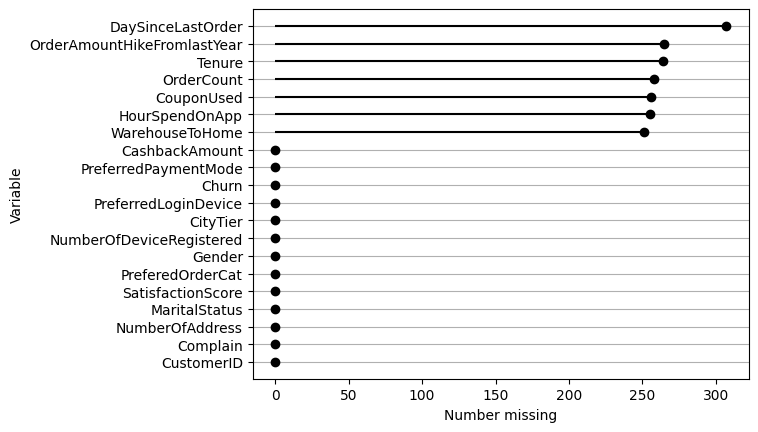

In [ ]:
ecomm_df.missing.missing_variable_plot()

In [ ]:
import missingno

<Axes: >

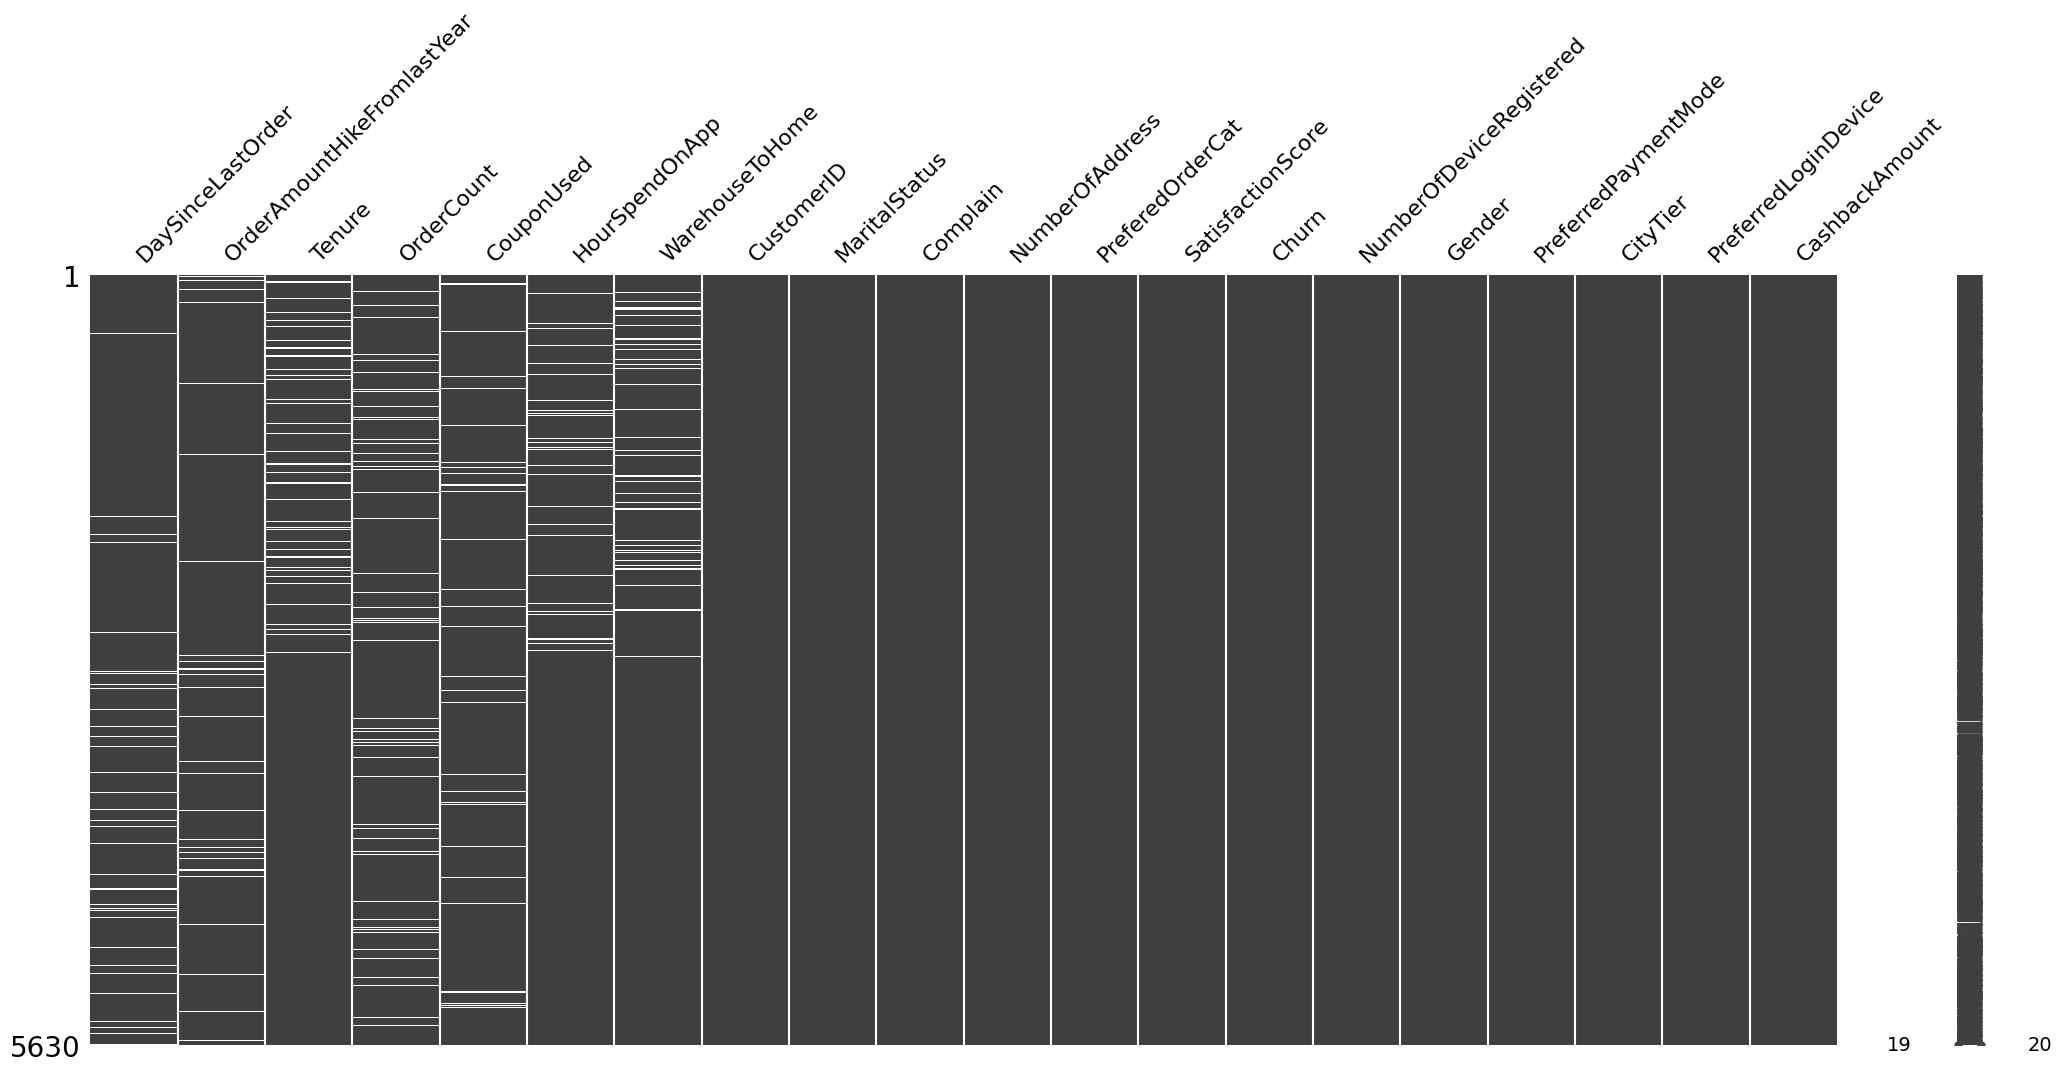

In [ ]:
(
    ecomm_df
    .missing.sort_variables_by_missingness()
    .pipe(missingno.matrix)
)

#IMPUTACIÓN DE DaySinceLastOrder



In [ ]:
round(ecomm_df.DaySinceLastOrder.mean())

5

In [ ]:
ecomm_df_DaySinceLastOrder_mean = ecomm_df.copy()

In [ ]:
ecomm_df_DaySinceLastOrder_mean['DaySinceLastOrder'] = ecomm_df_DaySinceLastOrder_mean['DaySinceLastOrder'].fillna(ecomm_df_DaySinceLastOrder_mean['DaySinceLastOrder'].mean())
sorted_DaySinceLastOrder_df = ecomm_df_DaySinceLastOrder_mean.sort_values(
    by=['DaySinceLastOrder'],
    ascending=False
)
sorted_DaySinceLastOrder_df

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
2040,52041,1,0.0,Mobile Phone,3,6.0,Debit Card,Male,2.0,4,Fashion,3,Married,6,0,11.0,5.0,11.0,46.0,206
4305,54306,0,4.0,Mobile Phone,1,12.0,COD,Female,3.0,4,Mobile Phone,5,Married,7,0,15.0,1.0,3.0,31.0,157
1490,51491,0,3.0,Phone,1,11.0,COD,Female,2.0,3,Mobile,5,Married,6,0,14.0,0.0,2.0,30.0,132
3076,53077,0,11.0,Mobile Phone,1,21.0,Debit Card,Female,4.0,4,Mobile Phone,5,Married,3,0,13.0,4.0,13.0,18.0,155
3565,53566,0,18.0,Mobile Phone,1,36.0,UPI,Male,3.0,4,Laptop & Accessory,2,Single,3,0,26.0,2.0,2.0,18.0,170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,51363,0,0.0,Computer,1,22.0,CC,Male,NaN,1,Mobile,1,Married,2,1,13.0,0.0,1.0,0.0,129
1902,51903,0,8.0,Computer,1,8.0,Debit Card,Female,3.0,3,Laptop & Accessory,5,Married,3,0,11.0,1.0,1.0,0.0,151
573,50574,0,8.0,Phone,3,24.0,Credit Card,Female,2.0,3,Laptop & Accessory,3,Divorced,2,0,16.0,1.0,1.0,0.0,146
260,50261,1,NaN,Computer,1,10.0,COD,Male,2.0,3,Mobile,2,Single,19,1,23.0,1.0,1.0,0.0,123


In [ ]:
print(f" media original : {ecomm_df['DaySinceLastOrder'].mean()} | media sin nulos : {ecomm_df_DaySinceLastOrder_mean['DaySinceLastOrder'].mean()}")

 media original : 4.543490512868683 | media sin nulos : 4.543490512868684


In [ ]:
ecomm_df_DaySinceLastOrder_ffill = ecomm_df.copy()

In [ ]:
ecomm_df_DaySinceLastOrder_ffill['DaySinceLastOrder'] = ecomm_df_DaySinceLastOrder_ffill['DaySinceLastOrder'].ffill()
sorted_DaySinceLastOrder_ffill = ecomm_df_DaySinceLastOrder_ffill.sort_values(
    by=['DaySinceLastOrder'],
    ascending=False
)
sorted_DaySinceLastOrder_ffill

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
2040,52041,1,0.0,Mobile Phone,3,6.0,Debit Card,Male,2.0,4,Fashion,3,Married,6,0,11.0,5.0,11.0,46.0,206
4305,54306,0,4.0,Mobile Phone,1,12.0,COD,Female,3.0,4,Mobile Phone,5,Married,7,0,15.0,1.0,3.0,31.0,157
1490,51491,0,3.0,Phone,1,11.0,COD,Female,2.0,3,Mobile,5,Married,6,0,14.0,0.0,2.0,30.0,132
3306,53307,0,25.0,Mobile Phone,3,33.0,E wallet,Female,4.0,4,Grocery,3,Divorced,4,0,15.0,NaN,5.0,18.0,288
3565,53566,0,18.0,Mobile Phone,1,36.0,UPI,Male,3.0,4,Laptop & Accessory,2,Single,3,0,26.0,2.0,2.0,18.0,170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,50478,0,3.0,Mobile Phone,1,8.0,Credit Card,Female,2.0,4,Laptop & Accessory,2,Single,6,1,24.0,1.0,1.0,0.0,169
476,50477,0,13.0,Computer,1,22.0,Credit Card,Male,2.0,4,Laptop & Accessory,3,Single,7,0,14.0,1.0,1.0,0.0,151
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
1831,51832,0,10.0,Mobile Phone,3,8.0,E wallet,Male,3.0,3,Laptop & Accessory,3,Married,5,1,11.0,0.0,1.0,0.0,196


In [ ]:
print(f" mediana original : {ecomm_df['DaySinceLastOrder'].mean()} | mediana sin nulos : {ecomm_df_DaySinceLastOrder_ffill['DaySinceLastOrder'].mean()}")

 mediana original : 4.543490512868683 | mediana sin nulos : 4.5626998223801065


In [ ]:
ecomm_df_DaySinceLastOrder_bfill = ecomm_df.copy()

In [ ]:
ecomm_df_DaySinceLastOrder_bfill['DaySinceLastOrder'] = ecomm_df_DaySinceLastOrder_bfill['DaySinceLastOrder'].bfill()
sorted_DaySinceLastOrder_bfill = ecomm_df_DaySinceLastOrder_bfill.sort_values(
    by=['DaySinceLastOrder'],
    ascending=False
)
sorted_DaySinceLastOrder_bfill

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
2040,52041,1,0.0,Mobile Phone,3,6.0,Debit Card,Male,2.0,4,Fashion,3,Married,6,0,11.0,5.0,11.0,46.0,206
4305,54306,0,4.0,Mobile Phone,1,12.0,COD,Female,3.0,4,Mobile Phone,5,Married,7,0,15.0,1.0,3.0,31.0,157
1490,51491,0,3.0,Phone,1,11.0,COD,Female,2.0,3,Mobile,5,Married,6,0,14.0,0.0,2.0,30.0,132
5238,55239,0,18.0,Mobile Phone,1,35.0,Debit Card,Male,3.0,4,Grocery,5,Married,5,0,14.0,NaN,15.0,18.0,288
3306,53307,0,25.0,Mobile Phone,3,33.0,E wallet,Female,4.0,4,Grocery,3,Divorced,4,0,15.0,NaN,5.0,18.0,288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,50398,0,10.0,Phone,1,16.0,Debit Card,Male,3.0,2,Mobile Phone,2,Single,4,0,17.0,1.0,1.0,0.0,147
2724,52725,1,0.0,Computer,2,28.0,UPI,Female,NaN,4,Mobile,4,Married,2,0,12.0,1.0,1.0,0.0,129
2723,52724,0,15.0,Mobile Phone,3,18.0,E wallet,Male,3.0,3,Laptop & Accessory,1,Married,4,1,12.0,1.0,1.0,0.0,151
2719,52720,0,60.0,Mobile Phone,3,27.0,Debit Card,Female,3.0,3,Grocery,1,Married,5,1,13.0,NaN,1.0,0.0,279


In [ ]:
print(f" mediana original : {ecomm_df['DaySinceLastOrder'].mean()} | mediana sin nulos : {ecomm_df_DaySinceLastOrder_bfill['DaySinceLastOrder'].mean()}")

 mediana original : 4.543490512868683 | mediana sin nulos : 4.5806394316163415


In [ ]:
ecomm_df_DaySinceLastOrder_interpolate = ecomm_df.copy()

In [ ]:
ecomm_df_DaySinceLastOrder_interpolate['DaySinceLastOrder'] = ecomm_df_DaySinceLastOrder_interpolate['DaySinceLastOrder'].interpolate()
sorted_DaySinceLastOrder_interpolate = ecomm_df_DaySinceLastOrder_interpolate.sort_values(
    by=['DaySinceLastOrder'],
    ascending=False
)
sorted_DaySinceLastOrder_interpolate

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
2040,52041,1,0.0,Mobile Phone,3,6.0,Debit Card,Male,2.0,4,Fashion,3,Married,6,0,11.0,5.0,11.0,46.0,206
4305,54306,0,4.0,Mobile Phone,1,12.0,COD,Female,3.0,4,Mobile Phone,5,Married,7,0,15.0,1.0,3.0,31.0,157
1490,51491,0,3.0,Phone,1,11.0,COD,Female,2.0,3,Mobile,5,Married,6,0,14.0,0.0,2.0,30.0,132
4846,54847,0,15.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,4,Mobile Phone,5,Single,4,1,14.0,2.0,3.0,18.0,172
4546,54547,0,11.0,Mobile Phone,1,21.0,Debit Card,Female,4.0,4,Mobile Phone,5,Married,3,0,13.0,11.0,13.0,18.0,155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,50980,0,2.0,Phone,1,NaN,Debit Card,Male,3.0,1,Mobile,3,Married,7,0,18.0,1.0,1.0,0.0,125
2481,52482,1,0.0,Phone,1,NaN,CC,Male,2.0,3,Mobile,4,Married,2,1,17.0,0.0,1.0,0.0,124
2043,52044,0,8.0,Phone,3,24.0,Credit Card,Female,2.0,3,Laptop & Accessory,3,Married,2,0,16.0,1.0,1.0,0.0,146
355,50356,1,NaN,Computer,3,18.0,Debit Card,Male,3.0,4,Mobile,5,Divorced,2,0,18.0,1.0,1.0,0.0,120


In [ ]:
print(f" mediana original : {ecomm_df['DaySinceLastOrder'].mean()} | mediana sin nulos : {ecomm_df_DaySinceLastOrder_interpolate['DaySinceLastOrder'].mean()}")

 mediana original : 4.543490512868683 | mediana sin nulos : 4.571669626998224


#GRAFICAMOS LA IMPUTACIÓN

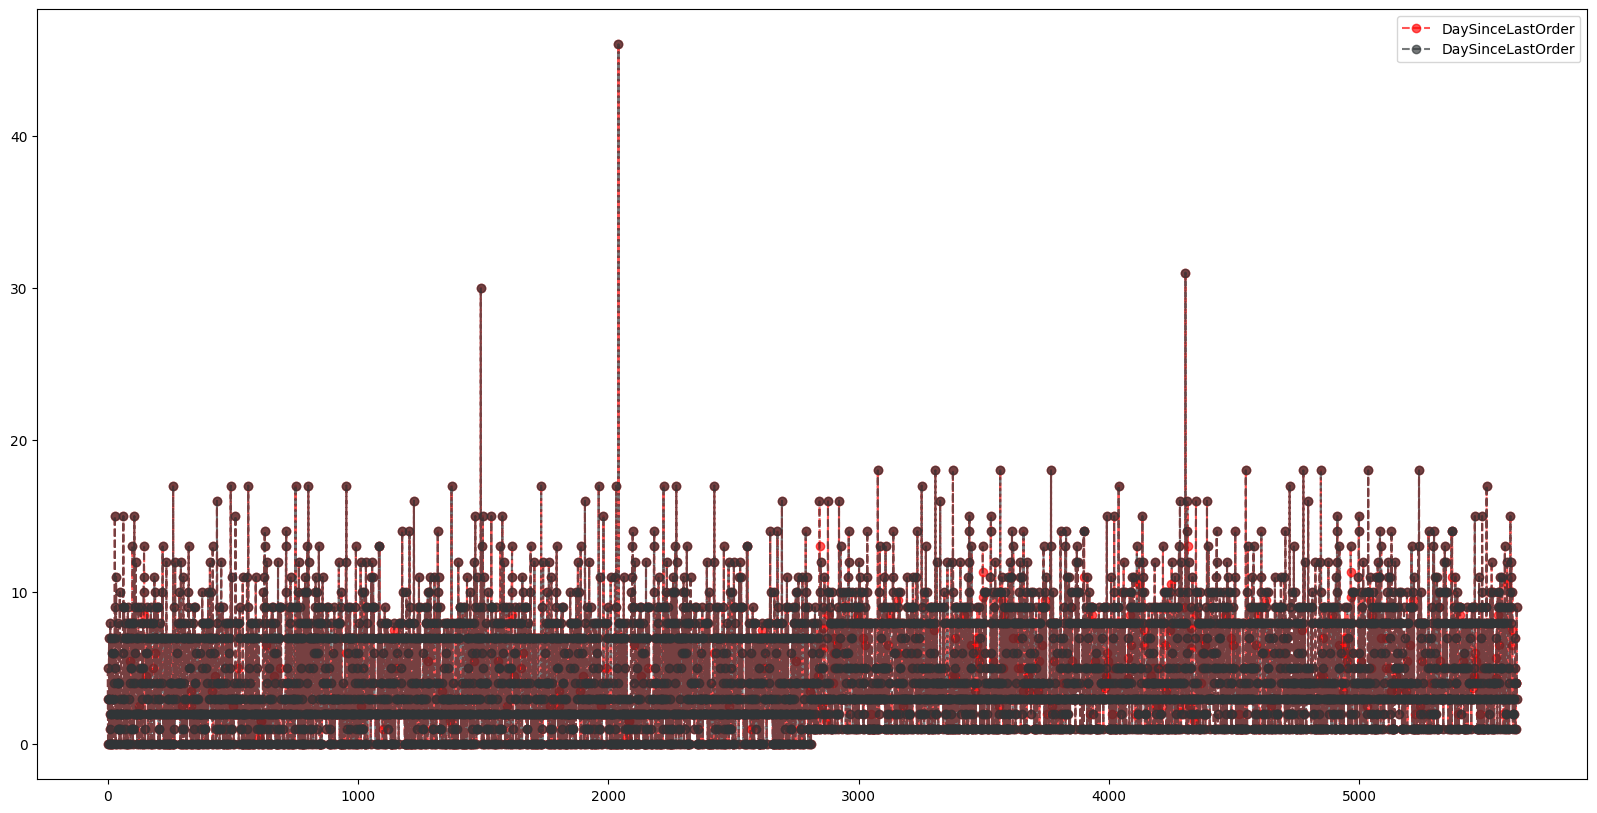

In [ ]:

plt.figure(figsize=(20,10))
ecomm_df['DaySinceLastOrder'].interpolate().plot(color='red',marker='o',alpha=6/9,linestyle='dashed')
ecomm_df['DaySinceLastOrder'].plot(color='#313638',marker='o',alpha=6/9,linestyle='dashed')
plt.legend()
plt.show()


#Codificacion de datos categoricos

In [34]:
!pip install pyjanitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 4.8 MB/s eta 0:00:00


In [35]:
import sklearn.compose
import sklearn.preprocessing
import janitor

In [36]:
ecomm_df.dtypes

,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


In [37]:
categorical_columns = ecomm_df.select_dtypes(object).columns
categorical_columns

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

#Transformador

In [38]:
categorical_transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),categorical_columns),
    remainder="passthrough"
)

#Transformando el dataset

In [39]:
ecomm_transformed_df = (
    pd.DataFrame(
        categorical_transformer.fit_transform(ecomm_df),
        columns = categorical_transformer.get_feature_names_out(),
        index=ecomm_df.index
    )
    .rename_columns(
        function = lambda x:x.removeprefix("ordinalencoder__")
    )
    .rename_columns(
        function = lambda x:x.removeprefix("remainder__")
    )
)
ecomm_transformed_df

/usr/local/lib/python3.11/dist-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.rename` instead.
  return method(self._obj, *args, **kwargs)


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1.0,4.0,0.0,2.0,2.0,50001.0,1.0,4.0,3.0,6.0,3.0,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,160.0
1,2.0,6.0,1.0,3.0,2.0,50002.0,1.0,NaN,1.0,8.0,3.0,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,121.0
2,2.0,4.0,1.0,3.0,2.0,50003.0,1.0,NaN,1.0,30.0,2.0,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.0
3,2.0,4.0,1.0,2.0,2.0,50004.0,1.0,0.0,3.0,15.0,2.0,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.0
4,2.0,0.0,1.0,3.0,2.0,50005.0,1.0,0.0,1.0,12.0,NaN,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0.0,3.0,1.0,2.0,1.0,55626.0,0.0,10.0,1.0,30.0,3.0,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.0,151.0
5626,1.0,3.0,1.0,0.0,1.0,55627.0,0.0,13.0,1.0,13.0,3.0,5.0,5.0,6.0,0.0,16.0,1.0,2.0,NaN,225.0
5627,1.0,4.0,1.0,2.0,1.0,55628.0,0.0,1.0,1.0,11.0,3.0,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.0,186.0
5628,0.0,3.0,1.0,2.0,1.0,55629.0,0.0,23.0,3.0,9.0,4.0,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.0,179.0
